# 16 - Pandas Visualisierungen: Daten analysieren und darstellen 📊

## Lernziele

Nach Abschluss dieses Notebooks können Sie:
- Das Konzept externer Bibliotheken erklären und Pandas importieren
- DataFrames aus Dictionaries erstellen und auf deren Spalten zugreifen
- CSV-Dateien laden und häufige Fehlerquellen erkennen und beheben
- Linien-, Balken-, Histogramm- und Scatter-Diagramme mit der Pandas `.plot()`-Methode erstellen
- Diagramme mit Titeln und Achsenbeschriftungen versehen
- Grundlegende Styling-Optionen anwenden

**Kompetenzstufen**: Verstehen, Anwenden

---

## Voraussetzungen

Für dieses Notebook sollten Sie folgende Konzepte beherrschen:
- Variablen und Datentypen (Notebooks 04-05)
- Komplexe Datentypen: Listen und Dictionaries (Notebook 06)
- Funktionen (Notebook 07)
- Operatoren (Notebook 08)
- Schleifen (Notebook 10)
- Fehlerbehandlung mit try-except (Notebook 11)

**Wichtig**: Dies ist das erste Notebook, in dem Sie **externe Bibliotheken** verwenden. Eine Bibliothek ist eine Sammlung von vorgefertigten Funktionen und Datenstrukturen, die Ihnen die Arbeit erleichtern. Das Konzept wird in diesem Notebook ausführlich erklärt.

Falls Sie diese Konzepte noch nicht sicher beherrschen, wiederholen Sie bitte die entsprechenden Notebooks.

---

## Externe Bibliotheken und das import-Statement

### Warum externe Bibliotheken?

Python bringt von Haus aus viele nützliche Funktionen mit, die Sie bereits kennen: `print()`, `len()`, `type()`, `range()` und viele mehr. Diese sogenannten "Built-in Functions" sind immer verfügbar und müssen nicht extra geladen werden.

Für spezialisierte Aufgaben wie Datenanalyse, wissenschaftliches Rechnen oder Webentwicklung reichen diese Grundfunktionen jedoch nicht aus. Hier kommen **externe Bibliotheken** ins Spiel: Sammlungen von Funktionen und Datenstrukturen, die von der Python-Community entwickelt wurden und für bestimmte Aufgabenbereiche optimiert sind.

Stellen Sie sich Python als einen Werkzeugkasten vor: Die eingebauten Funktionen sind wie Hammer, Schraubenzieher und Zange – universell einsetzbar. Externe Bibliotheken sind wie Spezialwerkzeuge für bestimmte Aufgaben: Ein Elektriker braucht andere Werkzeuge als ein Klempner.

Die beiden wichtigsten Bibliotheken für Datenanalyse sind:
- **Pandas**: Für die Verarbeitung und Analyse von tabellarischen Daten
- **Matplotlib**: Für die Erstellung von Diagrammen und Visualisierungen

### Das import-Statement

Um eine externe Bibliothek zu verwenden, müssen Sie sie zunächst **importieren**. Das geschieht mit dem `import`-Statement.

**Syntax**:
```python
import bibliothek
```

Nach dem Import können Sie alle Funktionen der Bibliothek über den Bibliotheksnamen aufrufen:
```python
bibliothek.funktion()
```

**Mit Alias (Kurzname)**:
```python
import bibliothek as alias
```

Ein Alias ist ein Kurzname, der das Schreiben vereinfacht. In der Python-Community haben sich bestimmte Aliase als Standard etabliert:
- `import pandas as pd` – Pandas wird als `pd` abgekürzt
- `import matplotlib.pyplot as plt` – Das pyplot-Modul von Matplotlib wird als `plt` abgekürzt

Diese Konventionen sollten Sie einhalten, da sie Ihren Code für andere Python-Entwickler leichter lesbar machen.

### Beispiel 1: Pandas importieren

Wir importieren nun die Pandas-Bibliothek mit dem Standard-Alias `pd`.

In [1]:
%pip install pandas
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
# Pandas-Bibliothek importieren mit dem Standard-Alias pd
import pandas as pd

**Erklärung**: Nach erfolgreicher Ausführung dieser Zelle steht Ihnen Pandas zur Verfügung. Es erscheint **keine Ausgabe** – das ist normal und bedeutet, dass der Import erfolgreich war. Bei einem Fehler würden Sie eine Meldung wie `ModuleNotFoundError: No module named 'pandas'` erhalten.

Ab jetzt können Sie alle Pandas-Funktionen über `pd.funktionsname()` aufrufen.

### Beispiel 2: Matplotlib importieren

Pandas nutzt im Hintergrund die Matplotlib-Bibliothek für Visualisierungen. Wir importieren das pyplot-Modul, um später Diagramme anzeigen zu können.

In [3]:
# Matplotlib pyplot-Modul importieren mit dem Standard-Alias plt
import matplotlib.pyplot as plt

**Erklärung**: Das pyplot-Modul ist ein Untermodul von Matplotlib (daher der Punkt: `matplotlib.pyplot`). Der Alias `plt` ist die etablierte Konvention. Die Funktion `plt.show()` werden wir später benötigen, um Diagramme anzuzeigen.

---

### Angeleitete Übung 1.1: Bibliotheken importieren

**Aufgabe**: Führen Sie beide Imports in einer einzigen Zelle aus. Dies ist die übliche Vorgehensweise am Anfang eines Notebooks oder Skripts.

**Hinweise**:
- Schritt 1: Schreiben Sie `import pandas as pd`
- Schritt 2: Schreiben Sie in der nächsten Zeile `import matplotlib.pyplot as plt`
- Schritt 3: Führen Sie die Zelle aus

In [4]:
# Ihr Code hier


**Musterlösung**:

<details>
<summary>Lösung anzeigen</summary>

```python
import pandas as pd
import matplotlib.pyplot as plt
```

**Erklärung**: 
- Beide Imports werden üblicherweise am Anfang eines Notebooks oder Skripts platziert
- Die Reihenfolge ist nicht entscheidend, aber es ist üblich, Standard-Bibliotheken vor spezialisierten zu importieren
- Keine Ausgabe bedeutet: Import erfolgreich
</details>

---

## DataFrame-Grundlagen

### Was ist ein DataFrame?

Ein DataFrame ist die zentrale Datenstruktur in Pandas. Sie können sich einen DataFrame wie eine **Excel-Tabelle** oder eine **Datenbanktabelle** vorstellen: Daten sind in Zeilen und Spalten organisiert.

Im Vergleich zu den Ihnen bekannten Python-Datenstrukturen:
- **Listen** können nur eindimensionale Daten speichern: `[1, 2, 3, 4]`
- **Dictionaries** speichern Schlüssel-Wert-Paare: `{"name": "Anna", "alter": 25}`
- **DataFrames** kombinieren beides: Tabellarische Struktur mit benannten Spalten

Ein DataFrame besteht aus:
- **Spalten**: Jede Spalte hat einen Namen und enthält Daten eines Typs (z.B. Zahlen, Texte)
- **Zeilen**: Jede Zeile repräsentiert einen Datensatz
- **Index**: Jede Zeile hat eine eindeutige Kennzeichnung (standardmäßig 0, 1, 2, ...)

### DataFrame aus Dictionary erstellen

Die einfachste Methode, einen DataFrame zu erstellen, ist die Verwendung eines Dictionaries. Dabei werden die **Schlüssel zu Spaltennamen** und die **Werte (Listen) zu Spalteninhalten**.

**Syntax**:
```python
df = pd.DataFrame(dictionary)
```

**Semantik**:
- `pd.DataFrame()`: Die Funktion zum Erstellen eines DataFrame
- `dictionary`: Ein Dictionary, bei dem jeder Schlüssel ein Spaltenname ist
- Alle Listen im Dictionary müssen die **gleiche Länge** haben
- `df`: Die Variable, in der der DataFrame gespeichert wird (übliche Abkürzung)

### Beispiel 3: DataFrame aus Dictionary erstellen

Wir erstellen einen DataFrame mit Informationen über Studierende.

In [5]:
# Dictionary mit Studierendendaten
daten = {
    "Name": ["Anna", "Ben", "Clara", "David"],
    "Alter": [22, 24, 21, 23],
    "Studiengang": ["Informatik", "BWL", "Informatik", "Physik"]
}

# DataFrame erstellen
df = pd.DataFrame(daten)

# DataFrame anzeigen
print(df)

    Name  Alter Studiengang
0   Anna     22  Informatik
1    Ben     24         BWL
2  Clara     21  Informatik
3  David     23      Physik


**Erwartete Ausgabe**:
```
    Name  Alter Studiengang
0   Anna     22  Informatik
1    Ben     24         BWL
2  Clara     21  Informatik
3  David     23      Physik
```

**Was ist passiert**:
- Die Dictionary-Schlüssel ("Name", "Alter", "Studiengang") wurden zu Spaltennamen
- Die Listen wurden zu Spalteninhalten
- Pandas hat automatisch einen Index (0, 1, 2, 3) erstellt
- Die Daten sind nun übersichtlich in Tabellenform dargestellt

### Auf Spalten zugreifen

Um auf eine einzelne Spalte zuzugreifen, verwenden Sie eckige Klammern mit dem Spaltennamen.

**Syntax**:
```python
spalte = df['Spaltenname']
```

### Beispiel 4: Auf Spalten zugreifen

In [6]:
# Zugriff auf die Spalte 'Alter'
alter_spalte = df['Alter']

print("Spalte 'Alter':")
print(alter_spalte)

Spalte 'Alter':
0    22
1    24
2    21
3    23
Name: Alter, dtype: int64


**Erklärung**: Das Ergebnis ist eine sogenannte **Series** – eine eindimensionale Pandas-Datenstruktur. Sie enthält die Werte der Spalte zusammen mit dem Index.

---

### Angeleitete Übung 2.1: Eigenen DataFrame erstellen

**Aufgabe**: Erstellen Sie einen DataFrame mit Informationen über 4 Produkte.

**Daten**:
- Produkte: Laptop, Tablet, Smartphone, Monitor
- Preise: 999, 499, 699, 299
- Verkauft: 45, 78, 132, 56

**Hinweise**:
- Schritt 1: Erstellen Sie ein Dictionary mit den Schlüsseln "Produkt", "Preis", "Verkauft"
- Schritt 2: Übergeben Sie das Dictionary an `pd.DataFrame()`
- Schritt 3: Geben Sie den DataFrame mit `print()` aus

In [7]:
# Ihr Code hier
import pandas as pd
# Dictionary mit Produktdaten
produkte_daten = {
    "Produkt": ["Laptop", "Tablet", "Smartphone", "Monitor"],
    "Preis": [999, 499, 699, 299],
    "Verkauft": [45, 78, 132, 56]
}

# DataFrame erstellen
df_produkte = pd.DataFrame(produkte_daten)

# Ausgabe
print(df_produkte)

      Produkt  Preis  Verkauft
0      Laptop    999        45
1      Tablet    499        78
2  Smartphone    699       132
3     Monitor    299        56


**Musterlösung**:

<details>
<summary>Lösung anzeigen</summary>

```python
# Dictionary mit Produktdaten
produkte_daten = {
    "Produkt": ["Laptop", "Tablet", "Smartphone", "Monitor"],
    "Preis": [999, 499, 699, 299],
    "Verkauft": [45, 78, 132, 56]
}

# DataFrame erstellen
df_produkte = pd.DataFrame(produkte_daten)

# Ausgabe
print(df_produkte)
```

**Erklärung**: 
- Das Dictionary hat drei Schlüssel, die zu drei Spalten werden
- Jede Liste hat vier Elemente, daher hat der DataFrame vier Zeilen
</details>

### Angeleitete Übung 2.2: Auf Spalten zugreifen

**Aufgabe**: Greifen Sie auf die Spalte "Preis" des Produkt-DataFrames zu und geben Sie sie aus.

**Hinweise**:
- Verwenden Sie `df_produkte['Preis']`
- Speichern Sie das Ergebnis in einer Variable
- Geben Sie die Variable mit `print()` aus

In [8]:
# Ihr Code hier
print(df_produkte["Verkauft"])

0     45
1     78
2    132
3     56
Name: Verkauft, dtype: int64


**Musterlösung**:

<details>
<summary>Lösung anzeigen</summary>

```python
# Auf Spalte 'Preis' zugreifen
preise = df_produkte['Preis']

# Ausgabe
print(preise)
```

**Erklärung**: 
- Der Spaltenname muss exakt so geschrieben werden wie im DataFrame (Groß-/Kleinschreibung beachten)
- Das Ergebnis ist eine Series mit den vier Preiswerten
</details>

---

## CSV-Dateien laden

### Was ist eine CSV-Datei?

CSV steht für **"Comma-Separated Values"** (kommagetrennte Werte). Eine CSV-Datei ist ein einfaches Textformat zum Speichern von Tabellendaten. Jede Zeile der Datei entspricht einer Tabellenzeile, und die Werte innerhalb einer Zeile werden durch ein Trennzeichen (meist Komma oder Semikolon) getrennt.

**Beispiel einer CSV-Datei**:
```
Name,Alter,Stadt
Anna,25,Berlin
Ben,30,Hamburg
Clara,22,München
```

CSV-Dateien sind weit verbreitet, weil sie:
- Von vielen Programmen unterstützt werden (Excel, Google Sheets, Datenbanken)
- Einfach zu lesen und zu erstellen sind
- Wenig Speicherplatz benötigen
- Plattformunabhängig sind

### CSV-Dateien mit Pandas laden

Pandas macht das Laden von CSV-Dateien sehr einfach mit der Funktion `pd.read_csv()`.

**Syntax**:
```python
df = pd.read_csv('dateiname.csv')
```

**Semantik**:
- `pd.read_csv()`: Pandas-Funktion zum Einlesen von CSV-Dateien
- `'dateiname.csv'`: Pfad zur CSV-Datei (kann relativ oder absolut sein)
- Die erste Zeile wird standardmäßig als Spaltenüberschrift interpretiert
- Pandas erkennt automatisch die Datentypen der Spalten

### Beispiel 5: CSV-Datei laden

Wir laden die Datei `verkaufsdaten.csv`, die sich im gleichen Verzeichnis wie dieses Notebook befindet.

In [42]:
# CSV-Datei laden
df_verkauf = pd.read_csv("verkaufszahlen.csv", sep=";")

# DataFrame anzeigen
print(df_verkauf)

        Monat  Umsatz  Kosten  Mitarbeiter
0      Januar   12000    8000            5
1     Februar   14000    9000            5
2       Maerz   13500    8500            6
3       April   15000    9500            6
4         Mai   16000   10000            7
5        Juni   18000   11000            7
6      August   15000   12000            6
7   September   12000   13000            7
8     Oktober   10000   10000            6
9    November   18000   12000            6
10   Dezember   24000   16000            5


**Erwartete Ausgabe**:
```
    Monat  Umsatz  Kosten  Mitarbeiter
0  Januar   12000    8000            5
1  Februar  14000    9000            5
2   Maerz   13500    8500            6
...
```

**Was ist passiert**:
- Pandas hat die CSV-Datei gelesen und automatisch in einen DataFrame umgewandelt
- Die erste Zeile der Datei wurde als Spaltenüberschrift verwendet
- Pandas hat die Datentypen erkannt (Texte und Zahlen)

### Häufige Fallstricke beim CSV-Laden

Beim Laden von CSV-Dateien können verschiedene Probleme auftreten. Es ist wichtig, diese zu kennen und beheben zu können.

#### Fallstrick 1: Datei nicht gefunden

**Fehler**: `FileNotFoundError: [Errno 2] No such file or directory`

**Ursachen**:
- Die Datei existiert nicht am angegebenen Ort
- Der Dateiname ist falsch geschrieben (Groß-/Kleinschreibung beachten!)
- Der Pfad ist falsch (relative vs. absolute Pfade)

**Lösung**: Überprüfen Sie den Dateinamen und den Pfad.

#### Fallstrick 2: Falsches Trennzeichen

CSV-Dateien können verschiedene Trennzeichen verwenden:
- **Komma** (`,`): International üblich
- **Semikolon** (`;`): In Deutschland häufig (wegen Dezimalkomma)
- **Tabulator** (`\t`): Bei manchen Exporten

**Problem**: Wenn das Trennzeichen falsch ist, werden alle Daten in eine einzige Spalte gequetscht.

**Lösung**: Verwenden Sie den Parameter `sep`:
```python
df = pd.read_csv('datei.csv', sep=';')  # Für Semikolon-getrennte Dateien
```

#### Fallstrick 3: Encoding-Probleme (Umlaute)

**Problem**: Umlaute (ä, ö, ü) und Sonderzeichen werden als kryptische Zeichen angezeigt.

**Ursache**: Die Datei verwendet eine andere Zeichenkodierung als erwartet.

**Lösung**: Verwenden Sie den Parameter `encoding`:
```python
df = pd.read_csv('datei.csv', encoding='utf-8')  # Standard
df = pd.read_csv('datei.csv', encoding='latin-1')  # Für ältere Windows-Dateien
```

### Beispiel 6: Fehlerbehandlung beim CSV-Laden

Mit der Ihnen bekannten `try-except`-Struktur können Sie Fehler beim Laden abfangen.

In [34]:
# Sicheres Laden einer CSV-Datei mit Fehlerbehandlung
try:
    df_test = pd.read_csv('verkaufsdaten.csv')
    print("Datei erfolgreich geladen!")
    print(df_test)
except FileNotFoundError:
    print("Fehler: Die Datei wurde nicht gefunden.")
    print("Überprüfen Sie den Dateinamen und den Pfad.")

Datei erfolgreich geladen!
        Monat  Umsatz  Kosten  Mitarbeiter
0      Januar   12000    8000            5
1     Februar   14000    9000            5
2       Maerz   13500    8500            6
3       April   15000    9500            6
4         Mai   16000   10000            7
5        Juni   18000   11000            7
6      August   15000   12000            6
7   September   12000   13000            7
8     Oktober   10000   10000            6
9    November   18000   12000            6
10   Dezember   24000   16000            5


**Erklärung**: Die `try-except`-Struktur verhindert, dass das Programm bei einem Fehler abstürzt. Stattdessen wird eine hilfreiche Fehlermeldung ausgegeben.

---

### Angeleitete Übung 3.1: CSV-Datei laden

**Aufgabe**: Laden Sie die Datei `verkaufsdaten.csv` und geben Sie die ersten Zeilen aus.

**Hinweise**:
- Verwenden Sie `pd.read_csv('verkaufsdaten.csv')`
- Speichern Sie das Ergebnis in einer Variable `df_uebung`
- Geben Sie den DataFrame mit `print()` aus

In [47]:
m = 42
n = 7
print(m)
print(n)

42
7


In [50]:
# Ihr Code hier
df_data = pd.read_csv("verkaufsdaten.csv")
print(df_data)
df_data

        Monat  Umsatz  Kosten  Mitarbeiter
0      Januar   12000    8000            5
1     Februar   14000    9000            5
2       Maerz   13500    8500            6
3       April   15000    9500            6
4         Mai   16000   10000            7
5        Juni   18000   11000            7
6      August   15000   12000            6
7   September   12000   13000            7
8     Oktober   10000   10000            6
9    November   18000   12000            6
10   Dezember   24000   16000            5


,Monat,Umsatz,Kosten,Mitarbeiter
0,Januar,12000,8000,5
1,Februar,14000,9000,5
2,Maerz,13500,8500,6
3,April,15000,9500,6
4,Mai,16000,10000,7
5,Juni,18000,11000,7
6,August,15000,12000,6
7,September,12000,13000,7
8,Oktober,10000,10000,6
9,November,18000,12000,6


**Musterlösung**:

<details>
<summary>Lösung anzeigen</summary>

```python
# CSV-Datei laden
df_uebung = pd.read_csv('verkaufsdaten.csv')

# Ausgabe
print(df_uebung)
```

**Erklärung**: 
- Die Datei wird automatisch eingelesen
- Die erste Zeile wird als Spaltenüberschrift verwendet
- Falls ein Fehler auftritt, überprüfen Sie, ob die Datei im richtigen Verzeichnis liegt
</details>

---

## Visualisierung mit Pandas .plot()

### Warum Datenvisualisierung?

Zahlen in Tabellen sind informativ, aber es fällt schwer, Muster und Trends in Zahlenkolonnen zu erkennen. Die grafische Darstellung von Daten ermöglicht es, Zusammenhänge auf einen Blick zu erfassen.

Betrachten Sie die Umsatzzahlen:
```
Januar: 12000, Februar: 14000, März: 13500, April: 15000, Mai: 16000, Juni: 18000
```

In einem Diagramm würden Sie sofort den steigenden Trend erkennen – in der Zahlenreihe ist das weniger offensichtlich.

### Die .plot()-Methode von Pandas

Pandas bietet eine einfache Möglichkeit, DataFrames direkt zu visualisieren: die `.plot()`-Methode. Diese nutzt im Hintergrund Matplotlib, erspart Ihnen aber viel Schreibarbeit.

**Syntax**:
```python
df.plot(kind='diagrammtyp')
plt.show()
```

**Wichtige Diagrammtypen**:
- `kind='line'`: Liniendiagramm (Standard)
- `kind='bar'`: Balkendiagramm
- `kind='hist'`: Histogramm
- `kind='scatter'`: Streudiagramm

### Beispiel 7: Erstes Liniendiagramm

Wir visualisieren die Umsatzentwicklung aus unseren Verkaufsdaten.

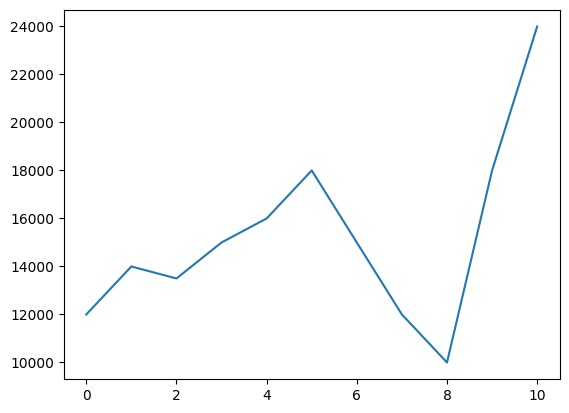

In [54]:
# Umsatzspalte als Liniendiagramm plotten
df_verkauf['Umsatz'].plot()

# Diagramm anzeigen
plt.show()

**Erklärung**:
- `df_verkauf['Umsatz']` wählt die Umsatzspalte aus
- `.plot()` erstellt ein Liniendiagramm (Standardeinstellung)
- `plt.show()` zeigt das Diagramm an
- Die x-Achse zeigt den Index (0-5), die y-Achse die Umsatzwerte

### Beispiel 8: Liniendiagramm mit Beschriftungen

Ein gutes Diagramm braucht Titel und Achsenbeschriftungen.

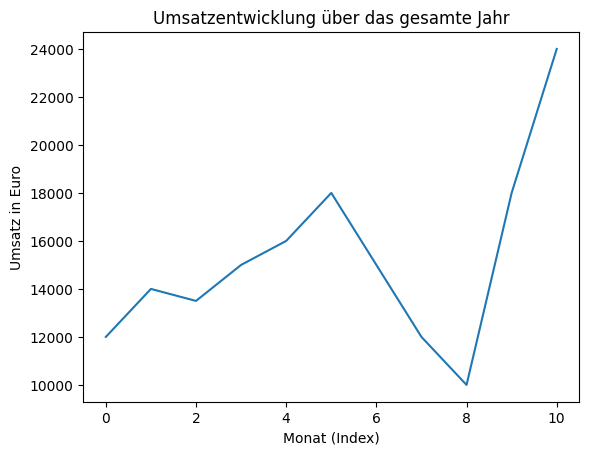

In [52]:
# Liniendiagramm mit Beschriftungen
df_verkauf['Umsatz'].plot(
    title='Umsatzentwicklung über das gesamte Jahr',
    xlabel='Monat (Index)',
    ylabel='Umsatz in Euro'
)

plt.show()

**Erklärung**:
- `title='...'` setzt den Titel über dem Diagramm
- `xlabel='...'` beschriftet die x-Achse
- `ylabel='...'` beschriftet die y-Achse
- Diese Parameter machen das Diagramm selbsterklärend

### Angeleitete Übung 4.1: Liniendiagramm erstellen

**Aufgabe**: Erstellen Sie ein Liniendiagramm der Kostenspalte mit vollständiger Beschriftung.

**Hinweise**:
- Verwenden Sie `df_verkauf['Kosten'].plot()`
- Fügen Sie einen passenden Titel hinzu
- Beschriften Sie die Achsen
- Vergessen Sie nicht `plt.show()`

In [14]:
# Ihr Code hier


**Musterlösung**:

<details>
<summary>Lösung anzeigen</summary>

```python
# Kostenentwicklung als Liniendiagramm
df_verkauf['Kosten'].plot(
    title='Kostenentwicklung erstes Halbjahr',
    xlabel='Monat (Index)',
    ylabel='Kosten in Euro'
)

plt.show()
```

**Erklärung**: 
- Die Struktur ist identisch zum Umsatz-Beispiel
- Nur die Spalte und die Beschriftungen wurden angepasst
</details>

### Angeleitete Übung 4.2: Mehrere Spalten plotten

**Aufgabe**: Plotten Sie Umsatz und Kosten in einem Diagramm, um sie zu vergleichen.

**Hinweise**:
- Wählen Sie mehrere Spalten mit `df_verkauf[['Umsatz', 'Kosten']]` (doppelte eckige Klammern!)
- Rufen Sie `.plot()` auf dieser Auswahl auf
- Pandas zeichnet automatisch beide Linien und fügt eine Legende hinzu

<Axes: >

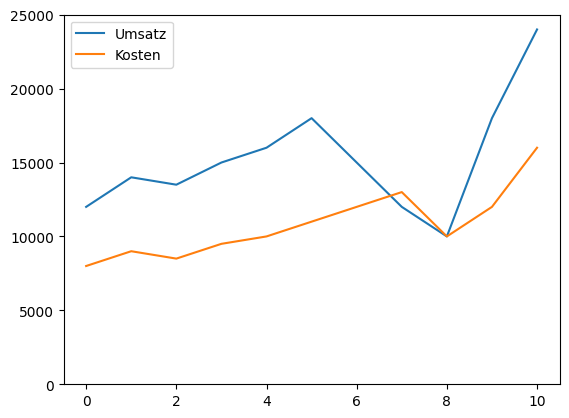

In [57]:
# Ihr Code hier
df_verkauf[["Umsatz", "Kosten"]].plot(ylim=(0,25000))

**Musterlösung**:

<details>
<summary>Lösung anzeigen</summary>

```python
# Umsatz und Kosten gemeinsam plotten
df_verkauf[['Umsatz', 'Kosten']].plot(
    title='Umsatz und Kosten im Vergleich',
    xlabel='Monat (Index)',
    ylabel='Betrag in Euro'
)

plt.show()
```

**Erklärung**: 
- Doppelte eckige Klammern `[['Spalte1', 'Spalte2']]` wählen mehrere Spalten als DataFrame aus
- Jede Spalte wird als separate Linie geplottet
- Pandas fügt automatisch eine Legende hinzu
</details>

---

## Balkendiagramme

### Wann Balkendiagramme?

Balkendiagramme eignen sich besonders für **kategoriale Daten** – also Daten, die in verschiedene Gruppen oder Kategorien eingeteilt sind. Typische Anwendungsfälle:
- Vergleich von Verkaufszahlen verschiedener Produkte
- Umfrageergebnisse
- Ausgaben nach Kategorien

Im Gegensatz zum Liniendiagramm (das Kontinuität suggeriert) steht jeder Balken für eine eigenständige Kategorie.

**Syntax**:
```python
df.plot(kind='bar')  # Vertikale Balken
df.plot(kind='barh')  # Horizontale Balken
```

### Beispiel 9: Einfaches Balkendiagramm

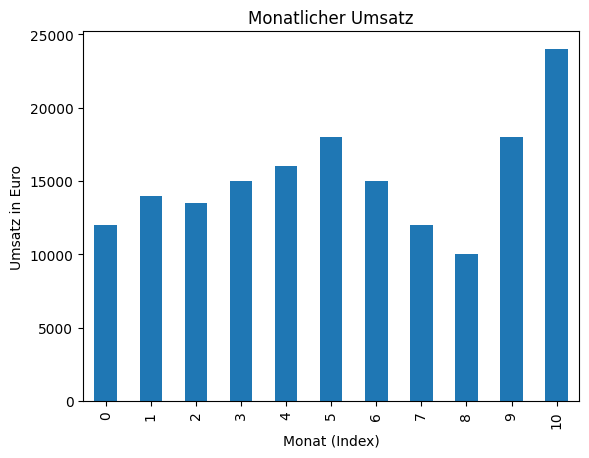

In [16]:
# Umsatz als Balkendiagramm
df_verkauf['Umsatz'].plot(
    kind='bar',
    title='Monatlicher Umsatz',
    xlabel='Monat (Index)',
    ylabel='Umsatz in Euro'
)

plt.show()

**Erklärung**:
- `kind='bar'` erzeugt ein Balkendiagramm
- Jeder Monat wird durch einen eigenen Balken dargestellt
- Die Höhe des Balkens entspricht dem Umsatzwert

### Beispiel 10: Balkendiagramm mit aussagekräftiger x-Achse

Statt der Index-Zahlen können wir die Monatsnamen auf der x-Achse anzeigen.

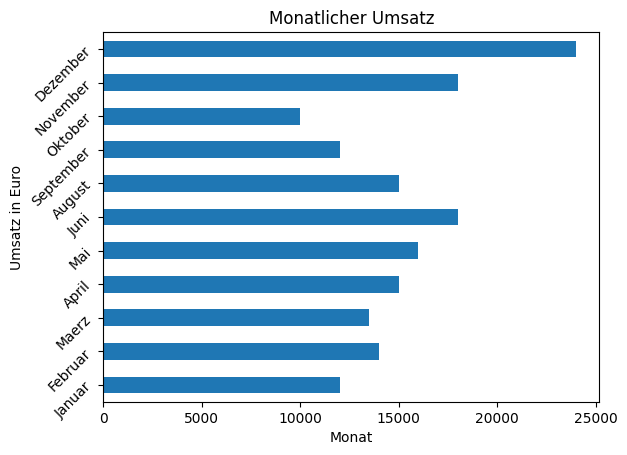

In [63]:
# Balkendiagramm mit Monatsnamen
df_verkauf.plot(
    kind='barh',
    x='Monat',
    y='Umsatz',
    title='Monatlicher Umsatz',
    xlabel='Monat',
    ylabel='Umsatz in Euro',
    legend=False,  # Legende ausblenden
    rot=45
)

plt.show()

**Erklärung**:
- `x='Monat'` verwendet die Monatsspalte für die x-Achse
- `y='Umsatz'` bestimmt, welche Spalte als Balkenhöhe verwendet wird
- `legend=False` blendet die Legende aus (nicht nötig bei nur einer Datenreihe)

### Angeleitete Übung 5.1: Balkendiagramm erstellen

**Aufgabe**: Erstellen Sie ein horizontales Balkendiagramm der Mitarbeiteranzahl pro Monat.

**Hinweise**:
- Verwenden Sie `kind='barh'` für horizontale Balken
- Setzen Sie `x='Monat'` und `y='Mitarbeiter'`
- Fügen Sie passende Beschriftungen hinzu

In [18]:
# Ihr Code hier


**Musterlösung**:

<details>
<summary>Lösung anzeigen</summary>

```python
# Horizontales Balkendiagramm der Mitarbeiteranzahl
df_verkauf.plot(
    kind='barh',
    x='Monat',
    y='Mitarbeiter',
    title='Mitarbeiteranzahl pro Monat',
    xlabel='Anzahl Mitarbeiter',
    ylabel='Monat',
    legend=False
)

plt.show()
```

**Erklärung**: 
- Bei horizontalen Balken werden xlabel und ylabel vertauscht
- Horizontale Balken sind praktisch, wenn die Kategorienamen lang sind
</details>

---

## Histogramme

### Was zeigen Histogramme?

Ein Histogramm zeigt die **Verteilung** von Daten. Es beantwortet die Frage: "Wie häufig kommen bestimmte Wertebereiche vor?"

Typische Anwendungsfälle:
- Altersverteilung einer Gruppe
- Notenverteilung in einer Prüfung
- Verteilung von Gehältern

Das Histogramm teilt die Daten in **Bins** (Intervalle) ein und zählt, wie viele Werte in jedes Intervall fallen.

**Syntax**:
```python
df['Spalte'].plot(kind='hist', bins=anzahl)
```

**Parameter**:
- `kind='hist'`: Erstellt ein Histogramm
- `bins`: Anzahl der Intervalle (Standard: 10)

### Beispiel 11: Histogramm erstellen

Wir erstellen zunächst einen DataFrame mit Testdaten für ein Histogramm.

In [64]:
# Testdaten für Histogramm: Prüfungsnoten von 30 Studierenden
noten_daten = {
    "Note": [1.0, 1.3, 1.3, 1.7, 2.0, 2.0, 2.0, 2.3, 2.3, 2.3,
             2.7, 2.7, 2.7, 2.7, 3.0, 3.0, 3.0, 3.0, 3.0, 3.3,
             3.3, 3.7, 3.7, 4.0, 4.0, 4.0, 4.0, 4.0, 5.0, 5.0]
}

df_noten = pd.DataFrame(noten_daten)
print(df_noten)

    Note
0    1.0
1    1.3
2    1.3
3    1.7
4    2.0
5    2.0
6    2.0
7    2.3
8    2.3
9    2.3
10   2.7
11   2.7
12   2.7
13   2.7
14   3.0
15   3.0
16   3.0
17   3.0
18   3.0
19   3.3
20   3.3
21   3.7
22   3.7
23   4.0
24   4.0
25   4.0
26   4.0
27   4.0
28   5.0
29   5.0


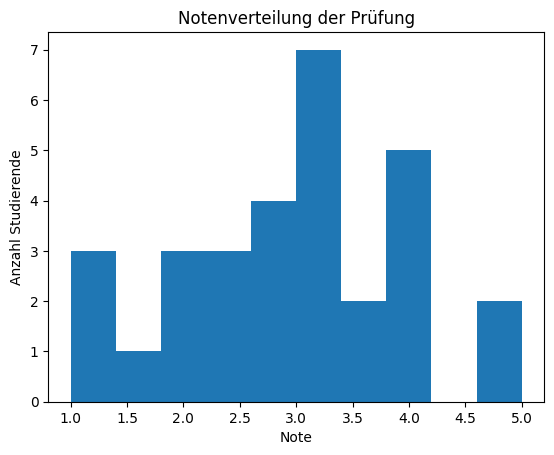

In [66]:
# Histogramm der Notenverteilung
df_noten['Note'].plot(
    kind='hist',
    bins=10,
    title='Notenverteilung der Prüfung',
    xlabel='Note',
    ylabel='Anzahl Studierende'
)

plt.show()

**Erklärung**:
- Das Histogramm zeigt, wie viele Studierende in welchem Notenbereich liegen
- `bins=10` teilt die Noten in 10 Intervalle ein
- Die Höhe jedes Balkens zeigt die Häufigkeit

### Angeleitete Übung 6.1: Histogramm mit verschiedenen Bins

**Aufgabe**: Erstellen Sie ein Histogramm der Umsatzdaten mit 5 Bins.

**Hinweise**:
- Verwenden Sie `df_verkauf['Umsatz'].plot(kind='hist', bins=5)`
- Fügen Sie passende Beschriftungen hinzu

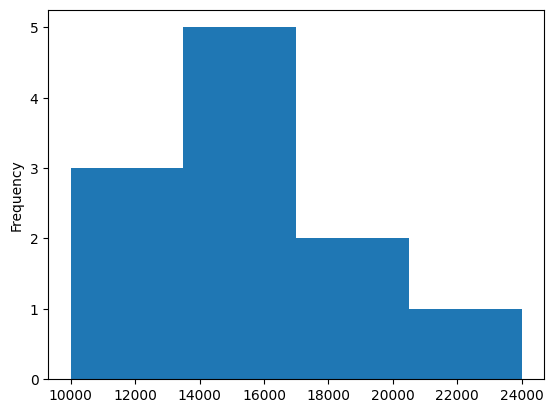

In [69]:
# Ihr Code hier
df_verkauf["Umsatz"].plot(kind="hist", bins=4)
plt.show()

**Musterlösung**:

<details>
<summary>Lösung anzeigen</summary>

```python
# Histogramm der Umsätze
df_verkauf['Umsatz'].plot(
    kind='hist',
    bins=5,
    title='Verteilung der Monatsumsätze',
    xlabel='Umsatz in Euro',
    ylabel='Häufigkeit'
)

plt.show()
```

**Erklärung**: 
- Bei nur 6 Datenpunkten ist die Verteilung nicht sehr aussagekräftig
- Histogramme sind besonders nützlich bei größeren Datenmengen
</details>

---

## Scatter Plots (Streudiagramme)

### Wann Scatter Plots?

Scatter Plots zeigen den **Zusammenhang zwischen zwei Variablen**. Jeder Punkt im Diagramm repräsentiert eine Beobachtung mit einem x- und einem y-Wert.

Typische Anwendungsfälle:
- Zusammenhang zwischen Lernzeit und Prüfungsnote
- Beziehung zwischen Umsatz und Kosten
- Korrelation zwischen Größe und Gewicht

**Syntax**:
```python
df.plot(kind='scatter', x='Spalte1', y='Spalte2')
```

**Parameter**:
- `kind='scatter'`: Erstellt ein Streudiagramm
- `x`: Spalte für die x-Achse (muss angegeben werden!)
- `y`: Spalte für die y-Achse (muss angegeben werden!)

### Beispiel 12: Scatter Plot erstellen

Wir untersuchen den Zusammenhang zwischen Umsatz und Kosten.

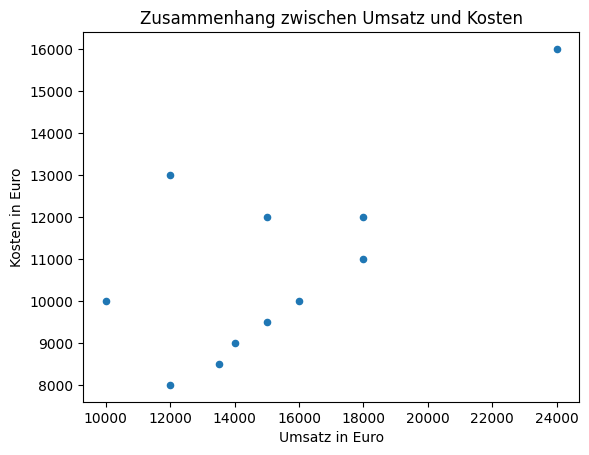

In [70]:
# Scatter Plot: Umsatz vs. Kosten
df_verkauf.plot(
    kind='scatter',
    x='Umsatz',
    y='Kosten',
    title='Zusammenhang zwischen Umsatz und Kosten',
    xlabel='Umsatz in Euro',
    ylabel='Kosten in Euro'
)

plt.show()

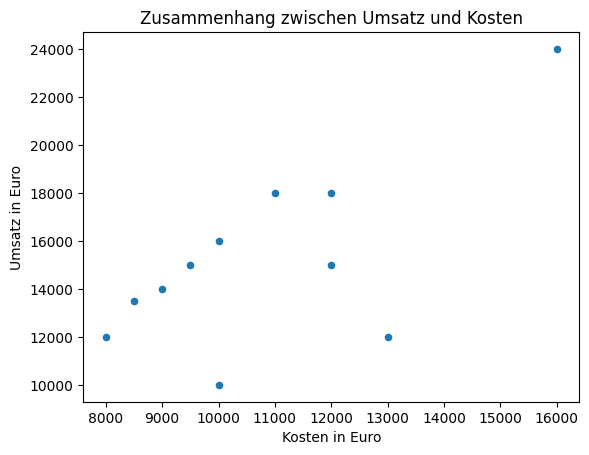

In [71]:
# Scatter Plot: Umsatz vs. Kosten
df_verkauf.plot(
    kind='scatter',
    x='Kosten',
    y='Umsatz',
    title='Zusammenhang zwischen Umsatz und Kosten',
    xlabel='Kosten in Euro',
    ylabel='Umsatz in Euro'
)

plt.show()

**Erklärung**:
- Jeder Punkt repräsentiert einen Monat
- Die x-Position zeigt den Umsatz, die y-Position die Kosten
- Das Muster zeigt: Höherer Umsatz geht mit höheren Kosten einher (positiver Zusammenhang)

### Beispiel 13: Scatter Plot mit zusätzlichen Daten

Wir erstellen einen größeren Datensatz, um den Scatter Plot interessanter zu machen.

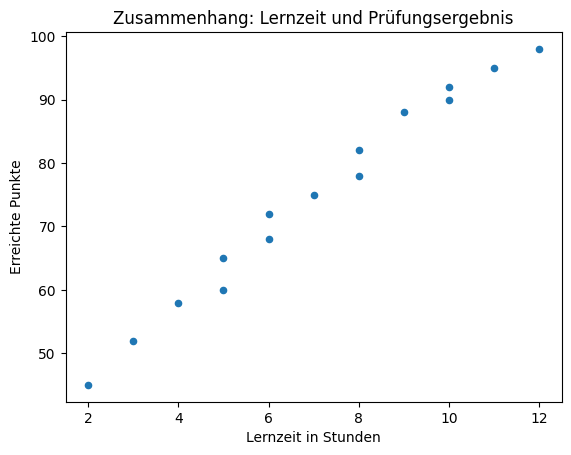

In [72]:
# Größerer Datensatz: Lernzeit vs. Prüfungsergebnis
lern_daten = {
    "Lernzeit_Stunden": [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 5, 6, 8, 10],
    "Punkte": [45, 52, 58, 65, 72, 75, 82, 88, 92, 95, 98, 60, 68, 78, 90]
}

df_lernen = pd.DataFrame(lern_daten)

# Scatter Plot
df_lernen.plot(
    kind='scatter',
    x='Lernzeit_Stunden',
    y='Punkte',
    title='Zusammenhang: Lernzeit und Prüfungsergebnis',
    xlabel='Lernzeit in Stunden',
    ylabel='Erreichte Punkte'
)

plt.show()

**Erklärung**:
- Das Muster zeigt deutlich: Mehr Lernzeit führt tendenziell zu mehr Punkten
- Die Punkte liegen nicht auf einer perfekten Linie (Streuung), was realistisch ist
- Scatter Plots sind ideal, um Korrelationen zu erkennen

### Angeleitete Übung 7.1: Scatter Plot erstellen

**Aufgabe**: Erstellen Sie einen Scatter Plot, der den Zusammenhang zwischen Mitarbeiteranzahl und Umsatz zeigt.

**Hinweise**:
- Verwenden Sie `df_verkauf.plot(kind='scatter', x='Mitarbeiter', y='Umsatz')`
- Fügen Sie passende Beschriftungen hinzu

In [24]:
# Ihr Code hier


**Musterlösung**:

<details>
<summary>Lösung anzeigen</summary>

```python
# Scatter Plot: Mitarbeiter vs. Umsatz
df_verkauf.plot(
    kind='scatter',
    x='Mitarbeiter',
    y='Umsatz',
    title='Zusammenhang: Mitarbeiter und Umsatz',
    xlabel='Anzahl Mitarbeiter',
    ylabel='Umsatz in Euro'
)

plt.show()
```

**Erklärung**: 
- Der Scatter Plot zeigt, ob mehr Mitarbeiter zu höherem Umsatz führen
- Bei unseren Daten ist ein positiver Zusammenhang erkennbar
</details>

---

## Styling

### Grundlegende Styling-Optionen

Sie können das Aussehen Ihrer Diagramme mit verschiedenen Parametern anpassen.

**Wichtige Parameter**:
- `color`: Farbe der Linie/Balken (z.B. 'red', 'blue', 'green', '#FF5733')
- `figsize`: Größe des Diagramms als Tupel (Breite, Höhe) in Zoll
- `alpha`: Transparenz (0 = unsichtbar, 1 = voll sichtbar)
- `grid`: Gitternetz anzeigen (True/False)

### Beispiel 14: Diagramm mit Styling

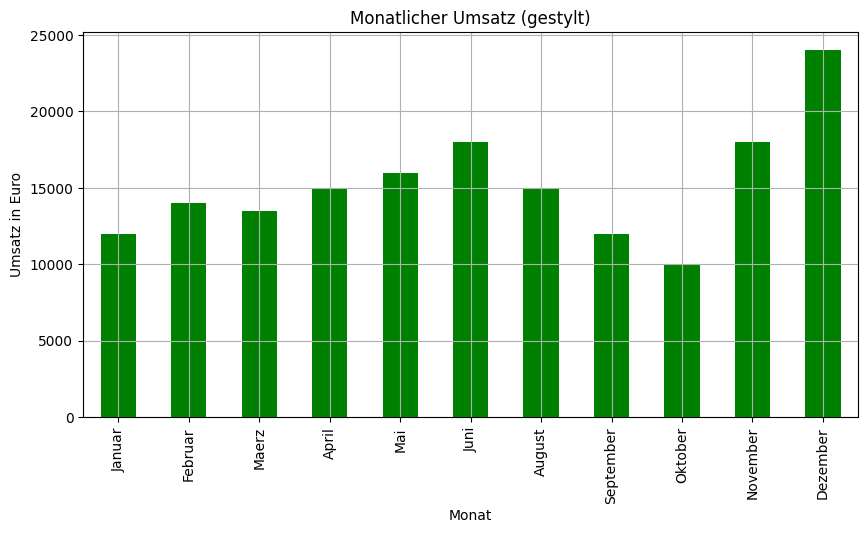

In [25]:
# Gestyltes Balkendiagramm
df_verkauf.plot(
    kind='bar',
    x='Monat',
    y='Umsatz',
    title='Monatlicher Umsatz (gestylt)',
    xlabel='Monat',
    ylabel='Umsatz in Euro',
    color='green',
    figsize=(10, 5),
    legend=False,
    grid=True
)

plt.show()

**Erklärung**:
- `color='green'` färbt die Balken grün
- `figsize=(10, 5)` macht das Diagramm 10 Zoll breit und 5 Zoll hoch
- `grid=True` zeigt ein Gitternetz für bessere Lesbarkeit

### Angeleitete Übung 8.1: Gestyltes Diagramm erstellen

**Aufgabe**: Erstellen Sie ein Liniendiagramm der Kosten mit roter Farbe und Gitternetz.

**Hinweise**:
- Verwenden Sie `color='red'`
- Aktivieren Sie das Gitternetz mit `grid=True`
- Setzen Sie eine größere Figurgröße mit `figsize=(10, 4)`

In [26]:
# Ihr Code hier


**Musterlösung**:

<details>
<summary>Lösung anzeigen</summary>

```python
# Gestyltes Liniendiagramm
df_verkauf['Kosten'].plot(
    title='Kostenentwicklung',
    xlabel='Monat (Index)',
    ylabel='Kosten in Euro',
    color='red',
    figsize=(10, 4),
    grid=True
)

plt.show()
```

**Erklärung**: 
- Die rote Farbe hebt die Linie hervor
- Das Gitternetz erleichtert das Ablesen der Werte
- Die größere Figurgröße verbessert die Lesbarkeit
</details>

---

## Abschlussübungen

Die folgenden Aufgaben testen Ihr Verständnis der in diesem Notebook erlernten Konzepte. Bearbeiten Sie die Aufgaben selbstständig und vergleichen Sie Ihre Lösung anschließend mit den Musterlösungen am Ende des Notebooks.

---

### Teil 1: Grundlegende Anwendung

**Kompetenzstufe**: Anwenden

Diese Aufgaben testen die direkte Anwendung der erlernten Konzepte.

---

**Aufgabe 1**: Erstellen Sie einen DataFrame mit Informationen über 5 Städte (Name, Einwohner in Tausend, Fläche in km²). Erstellen Sie dann ein Balkendiagramm, das die Einwohnerzahlen vergleicht.

**Beispieldaten**:
- Berlin: 3645 Tausend Einwohner, 892 km²
- Hamburg: 1841 Tausend Einwohner, 755 km²
- München: 1472 Tausend Einwohner, 311 km²
- Köln: 1086 Tausend Einwohner, 405 km²
- Frankfurt: 753 Tausend Einwohner, 248 km²

In [27]:
# Arbeitsbereich für Aufgabe 1


---

**Aufgabe 2**: Laden Sie die Datei `verkaufsdaten.csv` und erstellen Sie ein beschriftetes Liniendiagramm, das den Umsatzverlauf über die Monate zeigt. Verwenden Sie die Monatsnamen für die x-Achse.

In [28]:
# Arbeitsbereich für Aufgabe 2


---

### Teil 2: Transfer und Problemlösung

**Kompetenzstufe**: Analysieren & Erschaffen

Diese Aufgaben erfordern die Kombination mehrerer Konzepte und eigenständiges Problemlösen.

---

**Aufgabe 3**: Erstellen Sie einen DataFrame mit Daten über 10 Studierende (Name, Lernstunden pro Woche, Klausurnote). Erstellen Sie dann einen Scatter Plot, der den Zusammenhang zwischen Lernstunden und Klausurnote zeigt.

**Tipp**: Wählen Sie realistische Daten, bei denen ein Zusammenhang erkennbar ist (mehr Lernen = bessere Note).

In [29]:
# Arbeitsbereich für Aufgabe 3


---

**Aufgabe 4**: Erstellen Sie einen DataFrame mit eigenen Daten zu einem Thema Ihrer Wahl (mindestens 3 Spalten, 6 Zeilen). Visualisieren Sie die Daten mit mindestens zwei verschiedenen Diagrammtypen und beschriften Sie alle Diagramme vollständig.

In [30]:
# Arbeitsbereich für Aufgabe 4


---

## Zusammenfassung

In diesem Notebook haben Sie folgende Konzepte kennengelernt:

| Konzept | Syntax | Anwendungsfall |
|---------|--------|----------------|
| **Pandas importieren** | `import pandas as pd` | Bibliothek für Datenanalyse laden |
| **Matplotlib importieren** | `import matplotlib.pyplot as plt` | Visualisierungen ermöglichen |
| **DataFrame erstellen** | `pd.DataFrame(dictionary)` | Tabellarische Daten organisieren |
| **CSV laden** | `pd.read_csv('datei.csv')` | Externe Daten einlesen |
| **Spalte auswählen** | `df['Spaltenname']` | Auf Daten zugreifen |
| **Liniendiagramm** | `df.plot(kind='line')` | Zeitverläufe, Trends |
| **Balkendiagramm** | `df.plot(kind='bar')` | Kategorien vergleichen |
| **Histogramm** | `df.plot(kind='hist')` | Verteilungen zeigen |
| **Scatter Plot** | `df.plot(kind='scatter', x=, y=)` | Zusammenhänge visualisieren |
| **Beschriftungen** | `title=, xlabel=, ylabel=` | Diagramme erklären |
| **Diagramm anzeigen** | `plt.show()` | Visualisierung ausgeben |

**Zentrale Erkenntnisse**:

1. **Externe Bibliotheken erweitern Python**: Pandas und Matplotlib sind unverzichtbare Werkzeuge für Datenanalyse und -visualisierung.

2. **DataFrames sind tabellarische Datenstrukturen**: Sie ermöglichen effizientes Arbeiten mit strukturierten Daten.

3. **CSV-Dateien sind ein Standardformat**: Beim Laden können Fallstricke auftreten (Pfad, Trennzeichen, Encoding), die Sie nun erkennen und beheben können.

4. **Die .plot()-Methode vereinfacht Visualisierungen**: Mit wenigen Zeilen Code können Sie aussagekräftige Diagramme erstellen.

5. **Verschiedene Diagrammtypen für verschiedene Daten**: Liniendiagramme für Verläufe, Balkendiagramme für Kategorien, Histogramme für Verteilungen, Scatter Plots für Zusammenhänge.

---

## Musterlösungen

<details>
<summary>Lösung zu Aufgabe 1</summary>

```python
import pandas as pd
import matplotlib.pyplot as plt

# DataFrame mit Städtedaten erstellen
staedte_daten = {
    "Stadt": ["Berlin", "Hamburg", "München", "Köln", "Frankfurt"],
    "Einwohner_Tsd": [3645, 1841, 1472, 1086, 753],
    "Flaeche_km2": [892, 755, 311, 405, 248]
}

df_staedte = pd.DataFrame(staedte_daten)

# Balkendiagramm erstellen
df_staedte.plot(
    kind='bar',
    x='Stadt',
    y='Einwohner_Tsd',
    title='Einwohnerzahlen deutscher Großstädte',
    xlabel='Stadt',
    ylabel='Einwohner in Tausend',
    legend=False,
    color='steelblue'
)

plt.show()
```

**Erklärung**:
- Das Dictionary enthält drei Schlüssel für die drei Spalten
- Die Städte dienen als x-Achse, die Einwohnerzahlen als Balkenhöhe
- Die Legende ist ausgeblendet, da nur eine Datenreihe dargestellt wird
</details>

<details>
<summary>Lösung zu Aufgabe 2</summary>

```python
import pandas as pd
import matplotlib.pyplot as plt

# CSV-Datei laden
df = pd.read_csv('verkaufsdaten.csv')

# Liniendiagramm mit Monatsnamen
df.plot(
    kind='line',
    x='Monat',
    y='Umsatz',
    title='Umsatzentwicklung im ersten Halbjahr',
    xlabel='Monat',
    ylabel='Umsatz in Euro',
    legend=False,
    marker='o'  # Punkte an den Datenpunkten
)

plt.show()
```

**Erklärung**:
- Die CSV-Datei wird mit `pd.read_csv()` geladen
- `x='Monat'` verwendet die Monatsnamen für die x-Achse
- `marker='o'` fügt Punkte an den Datenpunkten hinzu
</details>

<details>
<summary>Lösung zu Aufgabe 3</summary>

```python
import pandas as pd
import matplotlib.pyplot as plt

# DataFrame mit Studierendendaten
studenten_daten = {
    "Name": ["Anna", "Ben", "Clara", "David", "Eva", 
             "Felix", "Greta", "Hans", "Ida", "Jan"],
    "Lernstunden": [5, 8, 12, 3, 10, 7, 15, 4, 9, 6],
    "Note": [2.7, 2.0, 1.3, 3.7, 1.7, 2.3, 1.0, 3.3, 2.0, 2.7]
}

df_studenten = pd.DataFrame(studenten_daten)

# Scatter Plot erstellen
df_studenten.plot(
    kind='scatter',
    x='Lernstunden',
    y='Note',
    title='Zusammenhang: Lernzeit und Klausurnote',
    xlabel='Lernstunden pro Woche',
    ylabel='Klausurnote',
    figsize=(8, 6)
)

plt.show()
```

**Erklärung**:
- Die Daten zeigen einen negativen Zusammenhang: Mehr Lernen führt zu niedrigeren (besseren) Noten
- Jeder Punkt repräsentiert einen Studierenden
- Der Scatter Plot macht den Zusammenhang sofort sichtbar

**Hinweis**: Bei Noten ist "niedriger = besser", daher die inverse Beziehung!
</details>

<details>
<summary>Lösung zu Aufgabe 4</summary>

```python
import pandas as pd
import matplotlib.pyplot as plt

# Eigener DataFrame: Wetterdaten einer Woche
wetter_daten = {
    "Tag": ["Montag", "Dienstag", "Mittwoch", "Donnerstag", "Freitag", "Samstag"],
    "Temperatur": [18, 20, 22, 21, 19, 17],
    "Sonnenstunden": [6, 8, 9, 7, 5, 4],
    "Niederschlag_mm": [0, 0, 2, 5, 8, 3]
}

df_wetter = pd.DataFrame(wetter_daten)

# Diagramm 1: Liniendiagramm der Temperatur
df_wetter.plot(
    kind='line',
    x='Tag',
    y='Temperatur',
    title='Temperaturverlauf der Woche',
    xlabel='Wochentag',
    ylabel='Temperatur in °C',
    color='red',
    marker='o',
    legend=False
)
plt.show()

# Diagramm 2: Balkendiagramm der Sonnenstunden
df_wetter.plot(
    kind='bar',
    x='Tag',
    y='Sonnenstunden',
    title='Sonnenstunden pro Tag',
    xlabel='Wochentag',
    ylabel='Sonnenstunden',
    color='orange',
    legend=False
)
plt.show()
```

**Erklärung**:
- Der DataFrame enthält Wetterdaten für eine Woche
- Das Liniendiagramm zeigt den Temperaturverlauf (Trend erkennbar)
- Das Balkendiagramm zeigt die Sonnenstunden (Vergleich zwischen Tagen)
- Beide Diagramme sind vollständig beschriftet

**Alternative Ansätze**:
- Sie könnten auch ein Histogramm der Temperaturen erstellen
- Oder einen Scatter Plot: Sonnenstunden vs. Temperatur
</details>